# Saccade detection notebook - BrainHack 2026 EyePrep project
Martin Szinte (martin.szinte@gmail.com) & Marianne Duyck (marianne.duyck@gmail.com)

### Description
Evaluation and implementation of two potential saccade detection model.
- CGTV method: Dai, Selesnick, Rizzo & Hudson, 2021, JoV (https://doi.org/10.1167/jov.21.6.8)
- Microsaccade method: Engbert & Mergenthaler, 2006, PNAS (https://doi.org/10.1073/pnas.0509557103)
- Eyelink method

### Steps:
- [ ] Load data as main eyeprep
- [ ] PLot basic x y pupil
- [ ] define models
- [ ] detect all saccade with model 1
- [ ] detect all saccade with model 2
- [ ] detect all saccade with model 3
- [ ] find a way to save data

In [29]:
import sys 
import os
sys.path.append("../eyeprep/utils")
from eyetrack_utils import (
    load_event_files,              # Load EyeLink event files
    extract_data,                  # Extract data from raw files
    blinkrm_pupil_off,             # Remove blinks with direct pupil detection
    blinkrm_pupil_off_smooth,      # Remove blinks with pupil detection and gaussian kernel 
    interpol_nans,                 # Interpolate missing values
    detrending,                    # Remove trends from signal
    downsample_to_targetrate,      # Change sampling rate
    moving_average_smoothing,      # Smooth with moving average
    gaussian_smoothing,            # Smooth with Gaussian kernel
    extract_eye_data_and_triggers, # Extract gaze and trial timing
    convert_to_dva                 # Convert to degrees of visual angle
)

from settings_utils import load_settings        # Load yml settings function 

from plot_utils import interactive_preproc_plot # Load plotting function for visualization 

import json
import numpy as np
import h5py
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import matplotlib.pyplot as plt

In [30]:
# Define experiment parameters and load configuration settings
EYEPREP_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
main_dir = os.path.abspath(os.getcwd())
project_dir = "data"
subject = "sub-01"
task = "SacLoc"  # Saccade localization task

# Get settings 
general_settings_path = os.path.abspath(os.path.join(main_dir, "../eye-tracking.yml"))
task_settings_path = os.path.abspath(os.path.join(main_dir, f"../eye-tracking_{task}.yml"))
settings = load_settings([general_settings_path, task_settings_path])
analysis_info = settings[0]

ses = analysis_info["session"]
eye = analysis_info["eye"]
num_run = analysis_info['num_run']

In [31]:
# Get data
df_event_runs = extract_data(main_dir, project_dir, subject, task, ses, num_run, eye, file_type="physioevents")
df_data_runs = extract_data(main_dir, project_dir, subject, task, ses, num_run, eye, file_type="physio")

# Convert timestamps to seconds (easier to work with than milliseconds)
df_data_runs[0]['timestamp'] = (df_data_runs[0]['timestamp'] - df_data_runs[0]['timestamp'][0]) * 1e-3


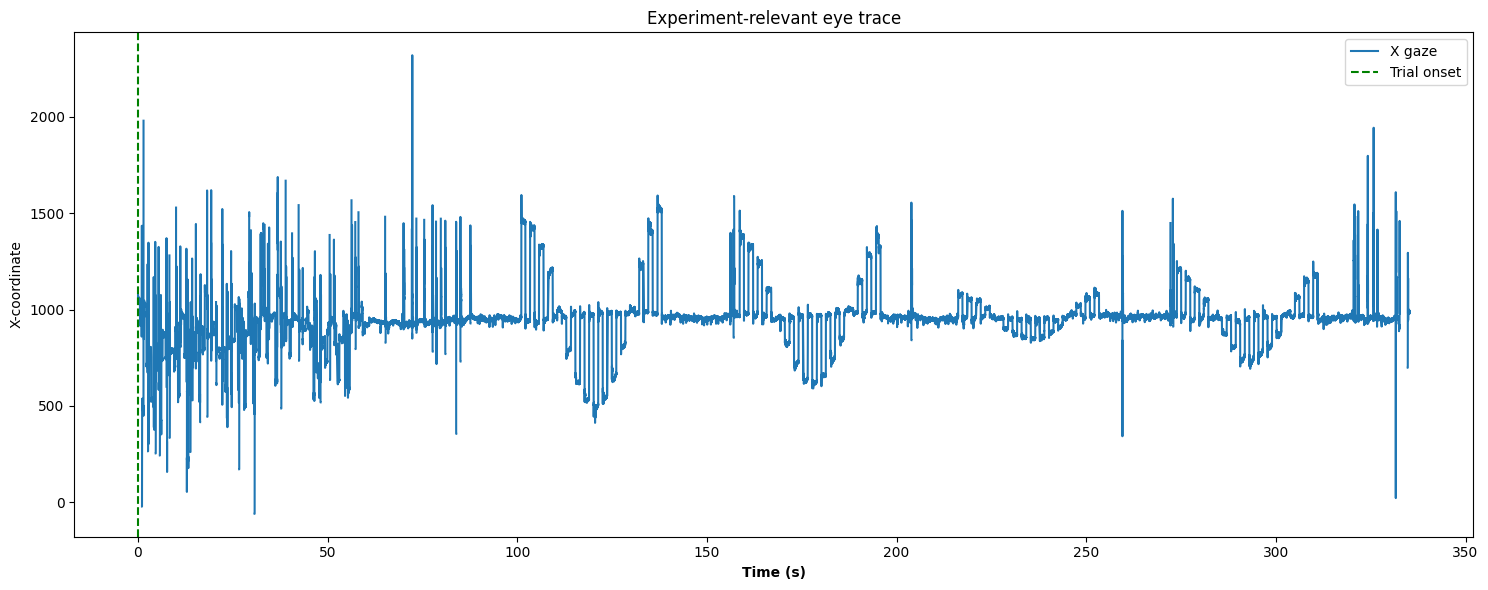

In [35]:
# --- Plot ---
plt.figure(figsize=(15, 6))
plt.plot(df_data_runs[0]['timestamp'], df_data_runs[0]['x_coordinate'], label='X gaze')

plt.axvline(0, color='green', linestyle='--', label='Trial onset')
# plt.axvline(
#     (time_end_eye - time_start_eye) * 1e-3,
#     color='red',
#     linestyle='--',
#     label='Trial offset'
# )

plt.xlabel('Time (s)', fontweight='bold')
plt.ylabel('X-coordinate')
plt.title('Experiment-relevant eye trace')
plt.legend()
plt.tight_layout()
plt.show()